In [1]:
!pip install rdkit -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.1/38.1 MB 51.6 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from rdkit import Chem
from rdkit.Chem import Descriptors

In [3]:
url = "https://raw.githubusercontent.com/deepchem/deepchem/master/datasets/delaney-processed.csv"

df = pd.read_csv(url)

df.head()

,Compound ID,ESOL predicted log solubility in mols per litre,Minimum Degree,Molecular Weight,Number of H-Bond Donors,Number of Rings,Number of Rotatable Bonds,Polar Surface Area,measured log solubility in mols per litre,smiles
0,Amigdalin,-0.974,1,457.432,7,3,7,202.32,-0.77,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...
1,Fenfuram,-2.885,1,201.225,1,2,2,42.24,-3.30,Cc1occc1C(=O)Nc2ccccc2
2,citral,-2.579,1,152.237,0,0,4,17.07,-2.06,CC(C)=CCCC(C)=CC(=O)
3,Picene,-6.618,2,278.354,0,5,0,0.00,-7.87,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43
4,Thiophene,-2.232,2,84.143,0,1,0,0.00,-1.33,c1ccsc1


In [4]:
print("Number of rows:", len(df))
print("\nColumn names:")
print(df.columns)

Number of rows: 1128

Column names:
Index(['Compound ID', 'ESOL predicted log solubility in mols per litre',
       'Minimum Degree', 'Molecular Weight', 'Number of H-Bond Donors',
       'Number of Rings', 'Number of Rotatable Bonds', 'Polar Surface Area',
       'measured log solubility in mols per litre', 'smiles'],
      dtype='object')


In [5]:
df[["smiles", "measured log solubility in mols per litre"]].head()

,smiles,measured log solubility in mols per litre
0,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...,-0.77
1,Cc1occc1C(=O)Nc2ccccc2,-3.30
2,CC(C)=CCCC(C)=CC(=O),-2.06
3,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43,-7.87
4,c1ccsc1,-1.33


In [6]:
print(df[["smiles", "measured log solubility in mols per litre"]].isnull().sum())

smiles                                       0
measured log solubility in mols per litre    0
dtype: int64


In [7]:
data = df[
    ["smiles", "measured log solubility in mols per litre"]
].copy()

data = data.dropna()

print("Rows after cleaning:", len(data))
data.head()

Rows after cleaning: 1128


,smiles,measured log solubility in mols per litre
0,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...,-0.77
1,Cc1occc1C(=O)Nc2ccccc2,-3.30
2,CC(C)=CCCC(C)=CC(=O),-2.06
3,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43,-7.87
4,c1ccsc1,-1.33


In [8]:
data["mol"] = data["smiles"].apply(Chem.MolFromSmiles)

print("Invalid molecules:", data["mol"].isnull().sum())

Invalid molecules: 0


In [9]:
data = data[data["mol"].notnull()].copy()

print("Final number of molecules:", len(data))

Final number of molecules: 1128


In [10]:
def calculate_descriptors(mol):
    return pd.Series({
        "MolWt": Descriptors.MolWt(mol),
        "LogP": Descriptors.MolLogP(mol),
        "TPSA": Descriptors.TPSA(mol),
        "HBD": Descriptors.NumHDonors(mol),
        "HBA": Descriptors.NumHAcceptors(mol),
        "RotatableBonds": Descriptors.NumRotatableBonds(mol),
        "RingCount": Descriptors.RingCount(mol)
    })

descriptor_df = data["mol"].apply(calculate_descriptors)

descriptor_df.head()

,MolWt,LogP,TPSA,HBD,HBA,RotatableBonds,RingCount
0,457.432,-3.10802,202.32,7.0,12.0,7.0,3.0
1,201.225,2.84032,42.24,1.0,2.0,2.0,2.0
2,152.237,2.87800,17.07,0.0,1.0,4.0,0.0
3,278.354,6.29940,0.00,0.0,0.0,0.0,5.0
4,84.143,1.74810,0.00,0.0,1.0,0.0,1.0


In [11]:
model_data = pd.concat(
    [
        data[
            ["smiles", "measured log solubility in mols per litre"]
        ].reset_index(drop=True),
        descriptor_df.reset_index(drop=True)
    ],
    axis=1
)

model_data.head()

,smiles,measured log solubility in mols per litre,MolWt,LogP,TPSA,HBD,HBA,RotatableBonds,RingCount
0,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...,-0.77,457.432,-3.10802,202.32,7.0,12.0,7.0,3.0
1,Cc1occc1C(=O)Nc2ccccc2,-3.30,201.225,2.84032,42.24,1.0,2.0,2.0,2.0
2,CC(C)=CCCC(C)=CC(=O),-2.06,152.237,2.87800,17.07,0.0,1.0,4.0,0.0
3,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43,-7.87,278.354,6.29940,0.00,0.0,0.0,0.0,5.0
4,c1ccsc1,-1.33,84.143,1.74810,0.00,0.0,1.0,0.0,1.0


In [12]:
model_data.describe()

,measured log solubility in mols per litre,MolWt,LogP,TPSA,HBD,HBA,RotatableBonds,RingCount
count,1128.000000,1128.000000,1128.000000,1128.000000,1128.000000,1128.000000,1128.000000,1128.000000
mean,-3.050102,203.937074,2.447520,34.872881,0.701241,2.069149,2.177305,1.390957
std,2.096441,102.738077,1.852875,35.383593,1.089727,2.109388,2.640974,1.318286
min,-11.600000,16.043000,-7.571400,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-4.317500,121.183000,1.414900,0.000000,0.000000,0.000000,0.000000,0.000000
50%,-2.860000,182.179000,2.339000,26.300000,0.000000,2.000000,1.000000,1.000000
75%,-1.600000,270.372000,3.402200,55.440000,1.000000,3.000000,3.000000,2.000000
max,1.580000,780.949000,10.388600,268.680000,11.000000,16.000000,23.000000,8.000000


In [13]:
features = [
    "MolWt",
    "LogP",
    "TPSA",
    "HBD",
    "HBA",
    "RotatableBonds",
    "RingCount"
]

X = model_data[features]

y = model_data[
    "measured log solubility in mols per litre"
]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1128, 7)
y shape: (1128,)


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (902, 7)
Testing data: (226, 7)


In [15]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

LinearRegression()

In [16]:
y_pred = linear_model.predict(X_test)

In [17]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 0.8114612741873206
RMSE: 1.0693495666199677
R2 Score: 0.7580799586498999


In [18]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [19]:
rf_pred = rf_model.predict(X_test)

In [20]:
rf_mae = mean_absolute_error(y_test, rf_pred)

rf_mse = mean_squared_error(y_test, rf_pred)

rf_rmse = np.sqrt(rf_mse)

rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest MAE:", rf_mae)
print("Random Forest RMSE:", rf_rmse)
print("Random Forest R2 Score:", rf_r2)

Random Forest MAE: 0.556660145956551
Random Forest RMSE: 0.8041498413756268
Random Forest R2 Score: 0.8631936003214872


In [21]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mae, rf_mae],
    "RMSE": [rmse, rf_rmse],
    "R2 Score": [r2, rf_r2]
})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,0.811461,1.06935,0.758080
1,Random Forest,0.556660,0.80415,0.863194


In [22]:
results.to_csv("solubility_model_results.csv", index=False)

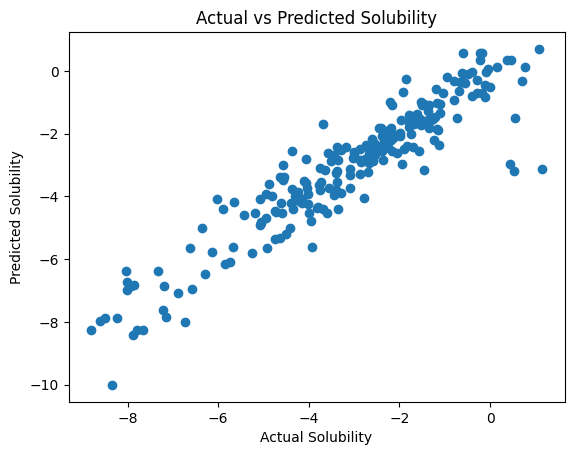

In [23]:
plt.scatter(y_test, rf_pred)

plt.xlabel("Actual Solubility")
plt.ylabel("Predicted Solubility")
plt.title("Actual vs Predicted Solubility")

plt.show()

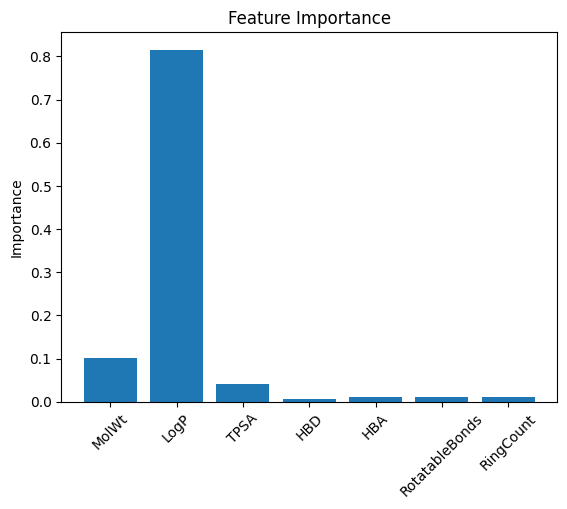

In [24]:
importance = rf_model.feature_importances_

plt.bar(features, importance)

plt.xticks(rotation=45)
plt.ylabel("Importance")
plt.title("Feature Importance")

plt.show()

## Conclusion

In this project, aqueous solubility was predicted using molecular descriptors and two machine-learning models: Linear Regression and Random Forest. Both models showed that simple molecular properties can be useful for estimating solubility. The Random Forest model was also used to examine feature importance and compare predicted values with actual solubility values. Overall, this project demonstrates a simple application of cheminformatics and machine learning in drug-related molecular property prediction.